* Dataset includes 239 patients and 60 variables
* Outcome variable (`at_risk`) distribution:

  * 124 not at risk (0)
  * 79 at risk (1)
  * 36 missing values (NaN), which reduces effective sample size for analyses

---

## ADT Agent Analysis (n = 192 complete cases)

### Overall result

* No statistically significant association between ADT agent and cardiovascular risk

  * Chi-square p = 0.2278

### Risk patterns (descriptive, not causal)

* Higher observed risk rates in several small-sample or combination therapy groups (all n ≤ 2), all showing 100% risk
* More reliable (larger n) groups:

  * Firmagon: 47.1% risk (8/17)
  * Bicalutamide: 44.4% risk (12/27)
  * Lupron: 34.0% risk (18/53)
  * Orgovyx: 32.5% risk (26/80) — lowest among major agents

### Key interpretation

* Apparent differences are driven largely by:

  * Very small combination-therapy groups (inflated extremes: 0% or 100%)
  * Moderate differences among major agents that do not reach statistical significance
* Pairwise comparisons confirm:

  * No statistically significant differences after correction
  * Some extreme odds ratios (inf/0) caused by zero-event groups, not meaningful signal

---

## NHT Agent Analysis (n = 203 complete cases)

### Overall result

* No statistically significant association between NHT agent and cardiovascular risk

  * Chi-square p = 0.4595

### Risk rates (cleaner structure than ADT data)

* Abiraterone: 44.9% (40/89) — highest observed risk
* Darolutamide: 35.4% (29/82)
* Enzalutamide: 31.6% (6/19)
* Apalutamide: 30.8% (4/13)

### Key patterns

* Moderate gradient:

  * Abiraterone shows consistently higher risk (~45%)
  * Other NHT agents cluster lower (~31–35%)
* Effect size trend:

  * Abiraterone vs others: OR ≈ 1.57, but not statistically significant (p ≈ 0.147)

### Robustness notes

* NHT analysis is more stable than ADT analysis because:

  * More standardized categories (4 agents vs many messy ADT combinations)
  * Adequate sample sizes across all groups (n ≥ 13)
* Still underpowered for small-to-moderate effect detection

---

## Overall Conclusions

### 1. Statistical significance

* Neither ADT nor NHT agent class shows statistically significant association with cardiovascular risk

### 2. Most consistent trend

* NHT agents:

  * Abiraterone consistently higher risk than other NHTs
* ADT agents:

  * More variability, but largely driven by small-sample artifacts

### 3. Data quality insight

* ADT dataset:

  * Highly fragmented with many rare combination entries
  * Produces unstable estimates (0% or 100% risk inflation)
* NHT dataset:

  * Cleaner structure and more reliable comparisons

### 4. Interpretation caution

* Observed differences should be treated as exploratory signals only
* Main limitation across both analyses is statistical power, especially for subgroup comparisons


In [44]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")
df = pd.read_csv(BASE_FILE)

print(f"Dataset shape: {df.shape}")
print(df['at_risk'].value_counts(dropna=False))

Dataset shape: (239, 60)
at_risk
0.0    124
1.0     79
NaN     36
Name: count, dtype: int64


In [49]:
def compute_risk_table(df, group_col):
    """Compute risk summary by group."""
    out = df.groupby(group_col).agg(
        at_risk_count=('at_risk', 'sum'),
        total_patients=('at_risk', 'count'),
        risk_rate=('at_risk', 'mean')
    ).sort_values('risk_rate', ascending=False)
    return out


def chi_square_test(df, group_col):
    """Run chi-square test for association."""
    table = pd.crosstab(df[group_col], df['at_risk'])
    chi2, p, dof, exp = chi2_contingency(table)
    return chi2, p, dof


def pairwise_fisher(df, group_col):
    """Each group vs all others (Fisher's exact test)."""
    results = []

    for g in df[group_col].unique():
        mask = (df[group_col] == g).astype(int)
        table = pd.crosstab(mask, df['at_risk'])

        if table.shape == (2, 2):
            odds, p = fisher_exact(table)

            results.append({
                group_col: g,
                "risk_rate": df[df[group_col] == g]['at_risk'].mean(),
                "risk_others": df[df[group_col] != g]['at_risk'].mean(),
                "odds_ratio": odds,
                "p_value": p,
                "significant": p < 0.05
            })

    return pd.DataFrame(results).sort_values("risk_rate", ascending=False)


def plot_risk_bar(risk_df, title, xlabel):
    """Horizontal bar plot of risk rates."""
    fig, ax = plt.subplots(figsize=(10, 6))

    rates = risk_df['risk_rate']
    colors = ['#d62728' if r > rates.mean() else '#2ca02c' for r in rates]

    bars = ax.barh(range(len(risk_df)), rates, color=colors)

    ax.axvline(rates.mean(), linestyle='--', color='black',
               label=f"Mean: {rates.mean():.1%}")

    ax.set_yticks(range(len(risk_df)))
    ax.set_yticklabels(risk_df.index)
    ax.set_xlabel("Risk Rate")
    ax.set_ylabel(xlabel)
    ax.set_title(title)
    ax.legend()

    # value labels
    for i, b in enumerate(bars):
        ax.text(b.get_width(), b.get_y() + b.get_height()/2,
                f"{rates.iloc[i]:.1%}",
                va='center', ha='left', fontsize=9)

    plt.tight_layout()
    plt.show()


ADT sample size: 192
                                   at_risk_count  total_patients  risk_rate
adt_agent                                                                  
bicalutamide + lupron                        1.0               1   1.000000
bicalutamide to lupron to orgovyx            2.0               2   1.000000
bicalutamide, then lupron                    1.0               1   1.000000
casodex to firmagon                          1.0               1   1.000000
lupon                                        1.0               1   1.000000
lupron + casodex to lupron                   2.0               2   1.000000
lupron, orgovyx (d/c)                        1.0               2   0.500000
Firmagon                                     8.0              17   0.470588
Bicalutamide                                12.0              27   0.444444
Lupron                                      18.0              53   0.339623
Orgovyx                                     26.0              80  

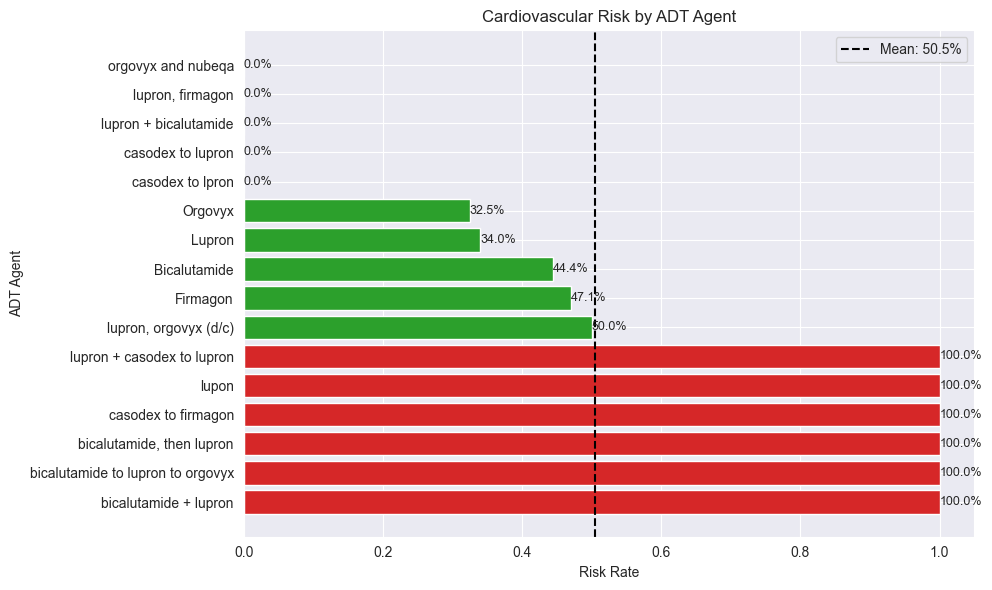

In [50]:
adt_df = df[df['adt_agent'].notna() & df['at_risk'].notna()].copy()

print("\nADT sample size:", len(adt_df))

# Risk table
adt_risk = compute_risk_table(adt_df, 'adt_agent')
print(adt_risk)

# Stats
chi2, p, dof = chi_square_test(adt_df, 'adt_agent')
print(f"\nChi-square ADT: p={p:.4f}")

# Pairwise
adt_pairwise = pairwise_fisher(adt_df, 'adt_agent')
print(adt_pairwise)

# Plot
plot_risk_bar(adt_risk, "Cardiovascular Risk by ADT Agent", "ADT Agent")


NHT sample size: 203
                   at_risk_count  total_patients  risk_rate
specific_nht_used                                          
Abiraterone                 40.0              89   0.449438
Darolutamide                29.0              82   0.353659
Enzalutamide                 6.0              19   0.315789
Apalutamide                  4.0              13   0.307692

Chi-square NHT: p=0.4595
  specific_nht_used  risk_rate  risk_others  odds_ratio   p_value  significant
2       Abiraterone   0.449438     0.342105    1.569859  0.146961        False
0      Darolutamide   0.353659     0.413223    0.776981  0.463630        False
3      Enzalutamide   0.315789     0.396739    0.701791  0.623515        False
1       Apalutamide   0.307692     0.394737    0.681481  0.769913        False


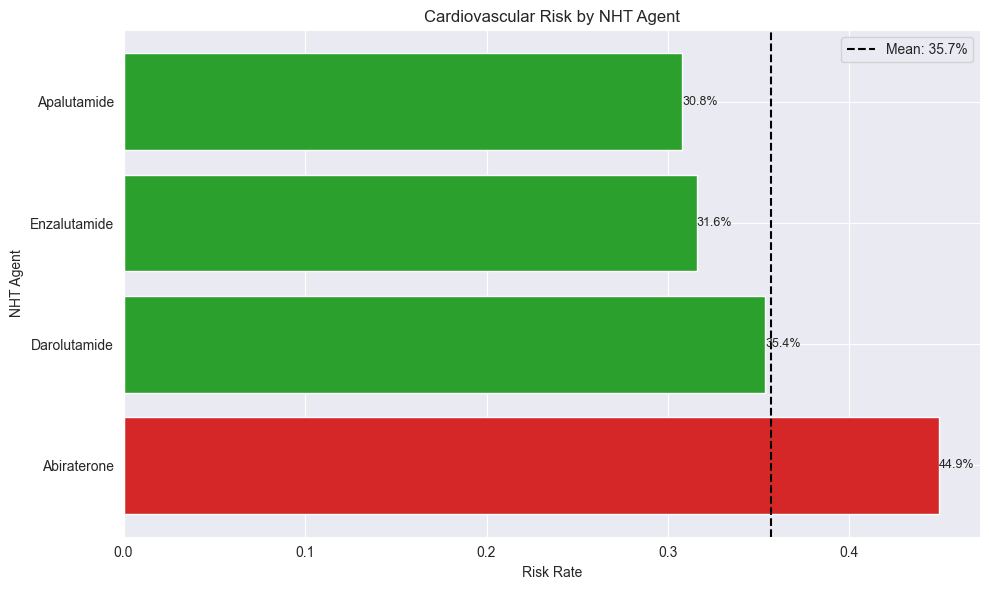

In [51]:
nht_df = df[df['specific_nht_used'].notna() & df['at_risk'].notna()].copy()

print("\nNHT sample size:", len(nht_df))

# Risk table
nht_risk = compute_risk_table(nht_df, 'specific_nht_used')
print(nht_risk)

# Stats
chi2, p, dof = chi_square_test(nht_df, 'specific_nht_used')
print(f"\nChi-square NHT: p={p:.4f}")

# Pairwise
nht_pairwise = pairwise_fisher(nht_df, 'specific_nht_used')
print(nht_pairwise)

# Plot
plot_risk_bar(nht_risk, "Cardiovascular Risk by NHT Agent", "NHT Agent")